# 03 PLS Regression for ERα pIC50

This notebook fits interpretable Partial Least Squares (PLS) regression models for ERα activity (`pIC50`) using molecular descriptors.

The aim is not to maximise leaderboard-style prediction accuracy. Instead, the goal is to:

- model the relationship between high-dimensional molecular descriptors and ERα `pIC50` using a linear latent-variable method;
- select the number of PLS components by cross-validation;
- evaluate cross-validated goodness-of-fit;
- interpret descriptor weights, coefficients, VIP scores, and descriptor-category contributions;
- prepare outputs for the later model-diagnostics notebook.

In [87]:
from pathlib import Path
import re
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_SPLITS = 5
MAX_COMPONENTS = 50

PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
PLS_FIGURES_DIR = FIGURES_DIR / "pls"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_DIRS = [DATA_RAW]

def find_file(candidate_names, search_dirs=SEARCH_DIRS):
    for directory in search_dirs:
        for name in candidate_names:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidate_names}")

def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:80] if text else "unknown"

# 1. Load Raw Data

In [70]:
FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx"]),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx"]),
    "admet": find_file(["ADMET.xlsx"]),
}

desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
admet_train = pd.read_excel(FILES["admet"], sheet_name="training")

print("Descriptor training shape:", desc_train.shape)
print("Activity training shape:", activity_train.shape)
print("ADMET training shape:", admet_train.shape)

display(desc_train.head(3))
display(activity_train.head(3))
display(admet_train.head(3))

Descriptor training shape: (1974, 730)
Activity training shape: (1974, 3)
ADMET training shape: (1974, 6)


,SMILES,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,...,MW,WTPT-1,WTPT-2,WTPT-3,WTPT-4,WTPT-5,WPATH,WPOL,XLogP,Zagreb
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,0,-0.2860,0.081796,126.1188,74.170169,12,12,64,31,...,439.218115,64.771680,2.089409,15.471445,8.858910,3.406628,3011,47,4.666,166
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,0,-0.8620,0.743044,131.9420,80.357341,12,12,70,33,...,467.249415,68.960024,2.089698,15.486947,8.863774,3.406648,3516,54,5.804,174
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,0,0.7296,0.532316,139.9304,74.064997,18,18,62,33,...,463.181729,68.748923,2.083301,18.011114,11.390412,3.406644,3542,52,2.964,176


,SMILES,IC50_nM,pIC50
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,2.5,8.602060
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,7.5,8.124939
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,3.1,8.508638


,SMILES,Caco-2,CYP3A4,hERG,HOB,MN
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,0,1,1,0,0
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,0,1,1,0,0
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,0,1,1,0,1


In [71]:
X_all = desc_train.drop(columns=["SMILES"]).apply(pd.to_numeric, errors="coerce")
y = activity_train["pIC50"].astype(float)

print("X_all shape:", X_all.shape)
print("pIC50 summary:")
display(y.describe())

X_all shape: (1974, 729)
pIC50 summary:


count    1974.000000
mean        6.586112
std         1.423023
min         2.455932
25%         5.382154
50%         6.580871
75%         7.568235
max        10.337242
Name: pIC50, dtype: float64

# 2. Load Data-Audit Outputs

In [72]:
preprocessing_path = RESULTS_DIR / "descriptor_preprocessing_candidates.csv"
preprocessing_candidates = pd.read_csv(preprocessing_path)

for col in ["is_constant", "is_near_constant", "is_binary_like", "is_rare_binary_like"]:
    preprocessing_candidates[col] = preprocessing_candidates[col].fillna(False).astype(bool)

preprocessing_candidates["candidate_super_block"] = preprocessing_candidates["candidate_super_block"].fillna("not_assigned")

print("Preprocessing candidates shape:", preprocessing_candidates.shape)
print("Candidate super-block counts:")
display(preprocessing_candidates["candidate_super_block"].value_counts(dropna=False).reset_index(name="n_descriptors"))
display(preprocessing_candidates.head(10))

Preprocessing candidates shape: (729, 24)
Candidate super-block counts:


,candidate_super_block,n_descriptors
0,block_X_local_electronic_atom_environment,553
1,block_Y_topological_connectivity_structure,136
2,not_assigned,40


,descriptor,variance,std,range,n_unique_values,unique_value_ratio,dominant_value,dominant_value_ratio,is_constant,dominant_value_ge_90pct,...,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,is_rare_binary_like,descriptor_category,candidate_super_block,remove_before_pca_pls,review_before_pca_pls,recommended_action
0,nB,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
1,nBondsQ,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Bond count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
2,nHsNH3p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
3,nHssNH2p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
4,nHsssNHp,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
5,nHmisc,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
6,nsLi,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
7,nssBe,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
8,nssssBem,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
9,nsBH2,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor


# 3. Define PLS Input Descriptor Sets

Three descriptor sets are compared:

1. **Primary set:** remove only constant descriptors.
2. **Sensitivity set A:** remove constant and non-binary near-constant descriptors, while retaining rare binary indicators.
3. **Sensitivity set B:** remove constant and all near-constant descriptors.

Rare binary indicators are not automatically removed in the primary analysis because they may represent rare but chemically meaningful structural features.

In [73]:
all_descriptors = [d for d in X_all.columns if d in preprocessing_candidates["descriptor"].values]

constant_descriptors = preprocessing_candidates.loc[preprocessing_candidates["is_constant"], "descriptor"].tolist()
near_constant_descriptors = preprocessing_candidates.loc[preprocessing_candidates["is_near_constant"], "descriptor"].tolist()
rare_binary_descriptors = preprocessing_candidates.loc[preprocessing_candidates["is_rare_binary_like"], "descriptor"].tolist()
non_binary_near_constant_descriptors = sorted(set(near_constant_descriptors) - set(rare_binary_descriptors))

def remove_descriptors(base, remove_list):
    remove_set = set(remove_list)
    return [d for d in base if d not in remove_set]

descriptor_sets = {
    "primary_remove_constant_only": remove_descriptors(all_descriptors, constant_descriptors),
    "sensitivity_remove_constant_nonbinary_near_constant": remove_descriptors(all_descriptors, constant_descriptors + non_binary_near_constant_descriptors),
    "sensitivity_remove_constant_all_near_constant": remove_descriptors(all_descriptors, constant_descriptors + near_constant_descriptors),
}

summary_descriptor_sets = pd.DataFrame([{"dataset_name": name, "n_descriptors": len(descs)} for name, descs in descriptor_sets.items()])
summary_descriptor_sets.to_csv(RESULTS_DIR / "pls_descriptor_set_summary.csv", index=False)

display(summary_descriptor_sets)
print("n constant descriptors:", len(constant_descriptors))
print("n near-constant descriptors:", len(near_constant_descriptors))
print("n rare binary descriptors:", len(rare_binary_descriptors))
print("n non-binary near-constant descriptors:", len(non_binary_near_constant_descriptors))

,dataset_name,n_descriptors
0,primary_remove_constant_only,504
1,sensitivity_remove_constant_nonbinary_near_con...,335
2,sensitivity_remove_constant_all_near_constant,320


n constant descriptors: 225
n near-constant descriptors: 184
n rare binary descriptors: 15
n non-binary near-constant descriptors: 169


# 4. PLS Cross-Validation Functions

PLS components are selected by 5-fold cross-validation. Standardisation is performed inside each fold through a `Pipeline`, preventing information leakage from validation folds into training folds.

The cross-validated `Q²` is computed as `1 - PRESS / TSS`, using out-of-fold predictions.

In [74]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def q2_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    press = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - press / tss)

def make_pls_pipeline(n_components):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components, scale=False, max_iter=200, tol=1e-6)),
    ])

def evaluate_pls_cv(X_df, y, dataset_name, max_components=MAX_COMPONENTS, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)
    max_components = int(min(max_components, X_df.shape[1], X_df.shape[0] - 1))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    summary_records = []
    fold_records = []
    prediction_records = []

    for n_components in range(1, max_components + 1):
        out_of_fold_pred = np.empty(len(y), dtype=float)
        fold_rmses, fold_maes, fold_r2s = [], [], []
        for fold_id, (train_idx, val_idx) in enumerate(cv.split(X_df), start=1):
            model = make_pls_pipeline(n_components)
            model.fit(X_df.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X_df.iloc[val_idx]).ravel()
            out_of_fold_pred[val_idx] = pred
            fold_rmse = rmse(y.iloc[val_idx], pred)
            fold_mae = float(mean_absolute_error(y.iloc[val_idx], pred))
            fold_r2 = float(r2_score(y.iloc[val_idx], pred))
            fold_rmses.append(fold_rmse)
            fold_maes.append(fold_mae)
            fold_r2s.append(fold_r2)
            fold_records.append({"dataset_name": dataset_name, "n_components": n_components, "fold": fold_id, "rmse": fold_rmse, "mae": fold_mae, "r2": fold_r2})
        prediction_records.append(pd.DataFrame({"dataset_name": dataset_name, "n_components": n_components, "y_true": y.values, "y_pred_cv": out_of_fold_pred, "residual_cv": y.values - out_of_fold_pred}))
        summary_records.append({
            "dataset_name": dataset_name,
            "n_components": n_components,
            "rmse_cv_global": rmse(y, out_of_fold_pred),
            "mae_cv_global": float(mean_absolute_error(y, out_of_fold_pred)),
            "q2_cv_global": q2_score(y, out_of_fold_pred),
            "r2_cv_global": float(r2_score(y, out_of_fold_pred)),
            "fold_rmse_mean": float(np.mean(fold_rmses)),
            "fold_rmse_sd": float(np.std(fold_rmses, ddof=1)),
            "fold_rmse_se": float(np.std(fold_rmses, ddof=1) / np.sqrt(n_splits)),
            "fold_mae_mean": float(np.mean(fold_maes)),
            "fold_r2_mean": float(np.mean(fold_r2s)),
        })

    summary = pd.DataFrame(summary_records)
    fold_metrics = pd.DataFrame(fold_records)
    predictions = pd.concat(prediction_records, ignore_index=True)
    best_row = summary.loc[summary["fold_rmse_mean"].idxmin()].copy()
    one_se_cutoff = best_row["fold_rmse_mean"] + best_row["fold_rmse_se"]
    one_se_row = summary[summary["fold_rmse_mean"] <= one_se_cutoff].sort_values("n_components").iloc[0].copy()
    summary["is_best_rmse"] = summary["n_components"] == int(best_row["n_components"])
    summary["is_one_se_choice"] = summary["n_components"] == int(one_se_row["n_components"])
    return {"summary": summary, "fold_metrics": fold_metrics, "predictions": predictions, "best_n_components": int(best_row["n_components"]), "one_se_n_components": int(one_se_row["n_components"])}

# 5. Cross-Validated Component Selection

The primary model removes only constant descriptors. Sensitivity analyses compare whether near-constant descriptor handling materially changes the cross-validated performance.

In [32]:
cv_results = {}
cv_summary_tables = []
cv_fold_tables = []

for dataset_name, descriptors in descriptor_sets.items():
    print("\n" + "=" * 80)
    print("Evaluating:", dataset_name)
    print("Number of descriptors:", len(descriptors))
    X_df = X_all[descriptors].copy()
    if X_df.isna().sum().sum() > 0:
        X_df = X_df.fillna(X_df.median())
    result = evaluate_pls_cv(X_df, y, dataset_name=dataset_name, max_components=min(MAX_COMPONENTS, len(descriptors)))
    cv_results[dataset_name] = result
    cv_summary_tables.append(result["summary"])
    cv_fold_tables.append(result["fold_metrics"])
    print("Best n_components by mean fold RMSE:", result["best_n_components"])
    print("One-SE selected n_components:", result["one_se_n_components"])
    display(result["summary"].head(10))

pls_cv_summary = pd.concat(cv_summary_tables, ignore_index=True)
pls_cv_fold_metrics = pd.concat(cv_fold_tables, ignore_index=True)
pls_cv_summary.to_csv(RESULTS_DIR / "pls_cv_summary.csv", index=False)
pls_cv_fold_metrics.to_csv(RESULTS_DIR / "pls_cv_fold_metrics.csv", index=False)
display(pls_cv_summary)


Evaluating: primary_remove_constant_only
Number of descriptors: 504
Best n_components by mean fold RMSE: 43
One-SE selected n_components: 20


,dataset_name,n_components,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
0,primary_remove_constant_only,1,1.146520,0.919825,0.350530,0.350530,1.144942,0.067074,0.029997,0.919822,0.349997,False,False
1,primary_remove_constant_only,2,1.025957,0.799016,0.479939,0.479939,1.024707,0.056648,0.025334,0.799026,0.479380,False,False
2,primary_remove_constant_only,3,0.961310,0.750531,0.543413,0.543413,0.960195,0.051888,0.023205,0.750542,0.542879,False,False
3,primary_remove_constant_only,4,0.935540,0.720170,0.567565,0.567565,0.934174,0.056589,0.025307,0.720182,0.566956,False,False
4,primary_remove_constant_only,5,0.913120,0.700792,0.588043,0.588043,0.912412,0.040050,0.017911,0.700797,0.587211,False,False
5,primary_remove_constant_only,6,0.892604,0.687361,0.606346,0.606346,0.892008,0.036250,0.016212,0.687360,0.605494,False,False
6,primary_remove_constant_only,7,0.904398,0.681856,0.595876,0.595876,0.902577,0.063871,0.028564,0.681856,0.595335,False,False
7,primary_remove_constant_only,8,0.904153,0.680482,0.596094,0.596094,0.900998,0.084053,0.037590,0.680475,0.595822,False,False
8,primary_remove_constant_only,9,0.902356,0.672902,0.597698,0.597698,0.897763,0.101270,0.045289,0.672889,0.597567,False,False
9,primary_remove_constant_only,10,0.912634,0.666726,0.588481,0.588481,0.905742,0.124828,0.055825,0.666717,0.588587,False,False



Evaluating: sensitivity_remove_constant_nonbinary_near_constant
Number of descriptors: 335
Best n_components by mean fold RMSE: 39
One-SE selected n_components: 23


,dataset_name,n_components,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
0,sensitivity_remove_constant_nonbinary_near_con...,1,1.186386,0.951012,0.304578,0.304578,1.183801,0.087254,0.039021,0.951005,0.304245,False,False
1,sensitivity_remove_constant_nonbinary_near_con...,2,1.003334,0.788823,0.502621,0.502621,1.002763,0.038282,0.017120,0.788839,0.501724,False,False
2,sensitivity_remove_constant_nonbinary_near_con...,3,0.947088,0.749044,0.556824,0.556824,0.946207,0.045969,0.020558,0.749056,0.556131,False,False
3,sensitivity_remove_constant_nonbinary_near_con...,4,0.926244,0.717694,0.576116,0.576116,0.925037,0.053147,0.023768,0.717711,0.575364,False,False
4,sensitivity_remove_constant_nonbinary_near_con...,5,0.914481,0.704890,0.586815,0.586815,0.913750,0.040969,0.018322,0.704901,0.585943,False,False
5,sensitivity_remove_constant_nonbinary_near_con...,6,0.893126,0.688468,0.605886,0.605886,0.892621,0.033549,0.015004,0.688474,0.604995,False,False
6,sensitivity_remove_constant_nonbinary_near_con...,7,0.894332,0.675943,0.604822,0.604822,0.893314,0.047543,0.021262,0.675950,0.604108,False,False
7,sensitivity_remove_constant_nonbinary_near_con...,8,0.889726,0.675092,0.608882,0.608882,0.888387,0.054318,0.024292,0.675090,0.608229,False,False
8,sensitivity_remove_constant_nonbinary_near_con...,9,0.889389,0.670229,0.609178,0.609178,0.886849,0.074698,0.033406,0.670220,0.608736,False,False
9,sensitivity_remove_constant_nonbinary_near_con...,10,0.884883,0.664960,0.613127,0.613127,0.882745,0.068396,0.030588,0.664957,0.612558,False,False



Evaluating: sensitivity_remove_constant_all_near_constant
Number of descriptors: 320
Best n_components by mean fold RMSE: 38
One-SE selected n_components: 24


,dataset_name,n_components,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
0,sensitivity_remove_constant_all_near_constant,1,1.186506,0.951050,0.304438,0.304438,1.183928,0.087147,0.038973,0.951043,0.304105,False,False
1,sensitivity_remove_constant_all_near_constant,2,1.002363,0.788101,0.503583,0.503583,1.001796,0.038156,0.017064,0.788118,0.502685,False,False
2,sensitivity_remove_constant_all_near_constant,3,0.946642,0.748943,0.557241,0.557241,0.945769,0.045767,0.020468,0.748956,0.556543,False,False
3,sensitivity_remove_constant_all_near_constant,4,0.925585,0.717573,0.576720,0.576720,0.924384,0.053002,0.023703,0.717592,0.575972,False,False
4,sensitivity_remove_constant_all_near_constant,5,0.915258,0.705018,0.586112,0.586112,0.914447,0.043181,0.019311,0.705031,0.585280,False,False
5,sensitivity_remove_constant_all_near_constant,6,0.896287,0.689142,0.603092,0.603092,0.895655,0.037584,0.016808,0.689148,0.602288,False,False
6,sensitivity_remove_constant_all_near_constant,7,0.899355,0.677831,0.600369,0.600369,0.897943,0.056202,0.025134,0.677838,0.599822,False,False
7,sensitivity_remove_constant_all_near_constant,8,0.896304,0.677023,0.603077,0.603077,0.894412,0.064865,0.029008,0.677022,0.602640,False,False
8,sensitivity_remove_constant_all_near_constant,9,0.901258,0.673119,0.598677,0.598677,0.897249,0.094575,0.042295,0.673110,0.598550,False,False
9,sensitivity_remove_constant_all_near_constant,10,0.897250,0.667841,0.602238,0.602238,0.893736,0.088402,0.039534,0.667839,0.601993,False,False


,dataset_name,n_components,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
0,primary_remove_constant_only,1,1.146520,0.919825,0.350530,0.350530,1.144942,0.067074,0.029997,0.919822,0.349997,False,False
1,primary_remove_constant_only,2,1.025957,0.799016,0.479939,0.479939,1.024707,0.056648,0.025334,0.799026,0.479380,False,False
2,primary_remove_constant_only,3,0.961310,0.750531,0.543413,0.543413,0.960195,0.051888,0.023205,0.750542,0.542879,False,False
3,primary_remove_constant_only,4,0.935540,0.720170,0.567565,0.567565,0.934174,0.056589,0.025307,0.720182,0.566956,False,False
4,primary_remove_constant_only,5,0.913120,0.700792,0.588043,0.588043,0.912412,0.040050,0.017911,0.700797,0.587211,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,sensitivity_remove_constant_all_near_constant,46,0.854655,0.648849,0.639108,0.639108,0.853394,0.051469,0.023018,0.648843,0.638709,False,False
146,sensitivity_remove_constant_all_near_constant,47,0.862819,0.648552,0.632180,0.632180,0.860911,0.063712,0.028493,0.648546,0.631939,False,False
147,sensitivity_remove_constant_all_near_constant,48,0.868044,0.649010,0.627712,0.627712,0.865700,0.070865,0.031692,0.649004,0.627532,False,False
148,sensitivity_remove_constant_all_near_constant,49,0.864969,0.647184,0.630344,0.630344,0.862819,0.067752,0.030300,0.647178,0.630128,False,False


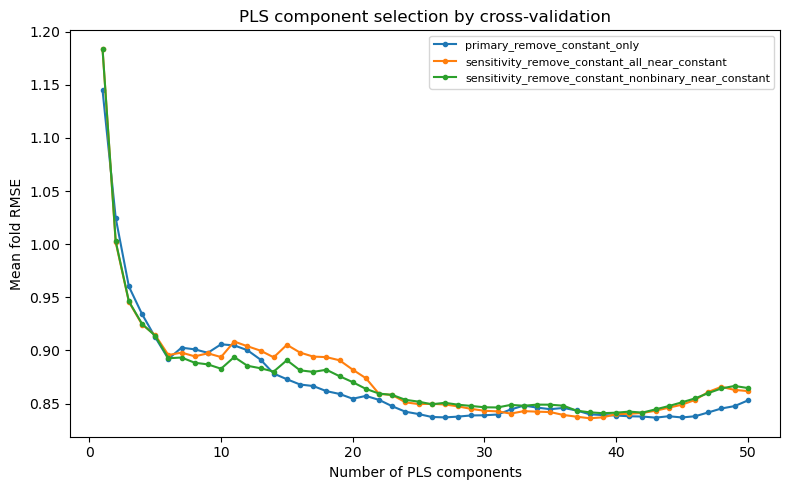

In [75]:
plt.figure(figsize=(8, 5))
for dataset_name, group in pls_cv_summary.groupby("dataset_name"):
    plt.plot(group["n_components"], group["fold_rmse_mean"], marker="o", markersize=3, label=dataset_name)
plt.xlabel("Number of PLS components")
plt.ylabel("Mean fold RMSE")
plt.title("PLS component selection by cross-validation")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_cv_rmse_by_components.png", dpi=200)
plt.show()

# 6. Select the Primary PLS Model

The final model in this notebook is fitted on the primary descriptor set using the one-standard-error component choice. The one-SE choice favours a simpler model when its cross-validated error is statistically close to the best observed error.

In [76]:
primary_dataset_name = "primary_remove_constant_only"
primary_descriptors = descriptor_sets[primary_dataset_name]
primary_cv = cv_results[primary_dataset_name]
selected_n_components = primary_cv["one_se_n_components"]
best_n_components = primary_cv["best_n_components"]

print("Primary descriptor set:", primary_dataset_name)
print("Number of descriptors:", len(primary_descriptors))
print("Best RMSE n_components:", best_n_components)
print("Selected one-SE n_components:", selected_n_components)

selected_cv_predictions = primary_cv["predictions"].query("n_components == @selected_n_components").copy()
selected_cv_predictions.insert(0, "SMILES", desc_train["SMILES"].astype(str).values)

selected_cv_predictions["pIC50"] = selected_cv_predictions["y_true"]
selected_cv_predictions["observed_pIC50"] = selected_cv_predictions["y_true"]
selected_cv_predictions["predicted_pIC50_cv"] = selected_cv_predictions["y_pred_cv"]
selected_cv_predictions["abs_residual_cv"] = selected_cv_predictions["residual_cv"].abs()

selected_cv_predictions.to_csv(RESULTS_DIR / "pls_cv_predictions_primary_selected_model.csv", index=False)

selected_summary = pls_cv_summary[(pls_cv_summary["dataset_name"] == primary_dataset_name) & (pls_cv_summary["n_components"] == selected_n_components)].copy()
selected_summary.to_csv(RESULTS_DIR / "pls_selected_model_cv_summary.csv", index=False)
display(selected_summary)
display(selected_cv_predictions.head())

Primary descriptor set: primary_remove_constant_only
Number of descriptors: 504
Best RMSE n_components: 43
Selected one-SE n_components: 20


,dataset_name,n_components,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_rmse_se,fold_mae_mean,fold_r2_mean,is_best_rmse,is_one_se_choice
19,primary_remove_constant_only,20,0.855541,0.641078,0.638359,0.638359,0.854507,0.046696,0.020883,0.641076,0.637908,False,True


,SMILES,dataset_name,n_components,y_true,y_pred_cv,residual_cv,pIC50,observed_pIC50,predicted_pIC50_cv,abs_residual_cv
37506,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,primary_remove_constant_only,20,8.602060,8.396612,0.205448,8.602060,8.602060,8.396612,0.205448
37507,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,primary_remove_constant_only,20,8.124939,8.359938,-0.234999,8.124939,8.124939,8.359938,0.234999
37508,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,primary_remove_constant_only,20,8.508638,8.395721,0.112918,8.508638,8.508638,8.395721,0.112918
37509,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.408935,8.042350,0.366586,8.408935,8.408935,8.042350,0.366586
37510,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.130768,8.219313,-0.088545,8.130768,8.130768,8.219313,0.088545


# 7. Cross-Validated Prediction Diagnostics

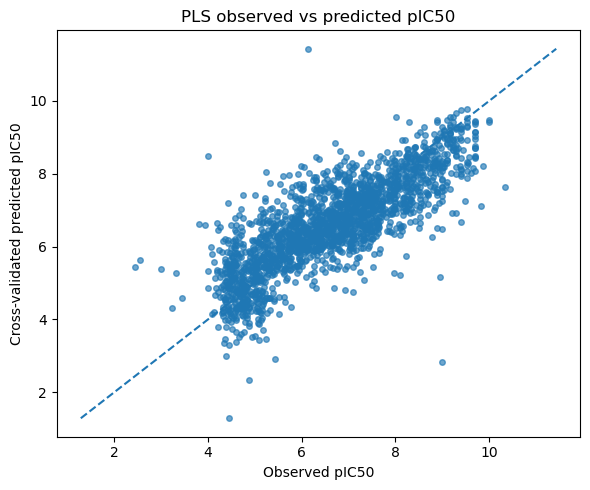

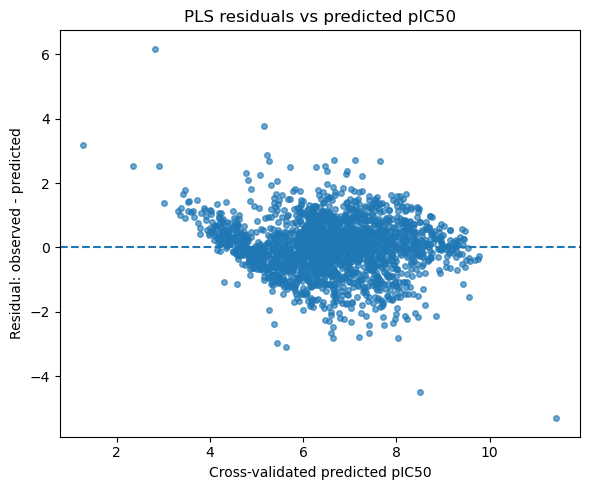

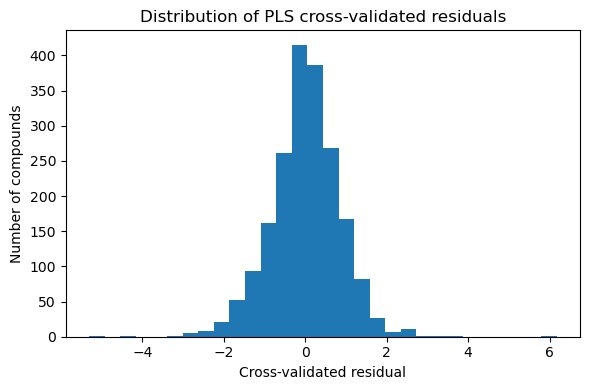

In [77]:
plt.figure(figsize=(6, 5))
plt.scatter(selected_cv_predictions["y_true"], selected_cv_predictions["y_pred_cv"], s=16, alpha=0.65)
min_val = min(selected_cv_predictions["y_true"].min(), selected_cv_predictions["y_pred_cv"].min())
max_val = max(selected_cv_predictions["y_true"].max(), selected_cv_predictions["y_pred_cv"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Observed pIC50")
plt.ylabel("Cross-validated predicted pIC50")
plt.title("PLS observed vs predicted pIC50")
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_observed_vs_predicted_cv.png", dpi=200)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(selected_cv_predictions["y_pred_cv"], selected_cv_predictions["residual_cv"], s=16, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Cross-validated predicted pIC50")
plt.ylabel("Residual: observed - predicted")
plt.title("PLS residuals vs predicted pIC50")
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_residual_vs_predicted_cv.png", dpi=200)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(selected_cv_predictions["residual_cv"], bins=30)
plt.xlabel("Cross-validated residual")
plt.ylabel("Number of compounds")
plt.title("Distribution of PLS cross-validated residuals")
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_cv_residual_distribution.png", dpi=200)
plt.show()

# 8. Fit Final PLS Model on the Full Training Set

In [88]:
X_primary = X_all[primary_descriptors].copy()
if X_primary.isna().sum().sum() > 0:
    X_primary = X_primary.fillna(X_primary.median())

final_model = make_pls_pipeline(selected_n_components)
final_model.fit(X_primary, y)

joblib.dump(final_model, MODEL_DIR / "final_pls_model_primary_selected.joblib")

model_metadata = {
    "selected_dataset_name": primary_dataset_name,
    "selected_n_components": int(selected_n_components),
    "n_descriptors": int(X_primary.shape[1]),
    "n_compounds": int(X_primary.shape[0]),
    "response": "pIC50",
}

pd.DataFrame([model_metadata]).to_csv(MODEL_DIR / "final_pls_model_metadata.csv", index=False)

pd.Series(X_primary.columns, name="descriptor").to_csv(MODEL_DIR / "final_pls_model_descriptors.csv", index=False)

final_scaler = final_model.named_steps["scaler"]
final_pls = final_model.named_steps["pls"]
X_primary_scaled = final_scaler.transform(X_primary)
y_fitted = final_model.predict(X_primary).ravel()

final_model_summary = pd.DataFrame([{
    "dataset_name": primary_dataset_name,
    "n_descriptors": len(primary_descriptors),
    "selected_n_components": selected_n_components,
    "best_rmse_n_components": best_n_components,
    "training_rmse": rmse(y, y_fitted),
    "training_mae": float(mean_absolute_error(y, y_fitted)),
    "training_r2": float(r2_score(y, y_fitted)),
    "cv_rmse_global": float(selected_summary["rmse_cv_global"].iloc[0]),
    "cv_mae_global": float(selected_summary["mae_cv_global"].iloc[0]),
    "cv_q2_global": float(selected_summary["q2_cv_global"].iloc[0]),
}])
final_model_summary.to_csv(RESULTS_DIR / "pls_final_model_summary.csv", index=False)
display(final_model_summary)

,dataset_name,n_descriptors,selected_n_components,best_rmse_n_components,training_rmse,training_mae,training_r2,cv_rmse_global,cv_mae_global,cv_q2_global
0,primary_remove_constant_only,504,20,43,0.728975,0.560801,0.737444,0.855541,0.641078,0.638359


# 9. PLS Scores and Latent-Component Interpretation

In [81]:
score_cols = [f"T{i+1}" for i in range(selected_n_components)]
pls_scores_df = pd.DataFrame(final_pls.x_scores_, columns=score_cols)
pls_scores_df.insert(0, "SMILES", desc_train["SMILES"].astype(str).values)
pls_scores_df["pIC50"] = y.values
pls_scores_df["IC50_nM"] = activity_train["IC50_nM"].values

for col in admet_train.columns:
    if col != "SMILES":
        pls_scores_df[col] = admet_train[col].values
pls_scores_df.to_csv(RESULTS_DIR / "pls_scores_primary_selected_model.csv", index=False)
display(pls_scores_df.head())

,SMILES,T1,T2,T3,T4,T5,T6,T7,T8,T9,...,T18,T19,T20,pIC50,IC50_nM,Caco-2,CYP3A4,hERG,HOB,MN
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,7.128091,-3.242561,-0.199723,5.729945,-1.943140,3.168406,1.073023,-2.984232,-2.630461,...,-0.466236,1.461166,0.010963,8.602060,2.5,0,1,1,0,0
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,9.407537,-3.597529,0.021948,5.492081,-1.104858,3.261067,0.548181,-4.390921,-1.938760,...,-0.326426,1.034407,-0.389273,8.124939,7.5,0,1,1,0,0
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,9.320795,-5.361821,2.167094,1.570192,-1.563453,0.647988,-0.389060,-4.458250,0.096742,...,0.005279,0.743035,0.064997,8.508638,3.1,0,1,1,0,1
3,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,8.977082,-3.406055,-0.326472,4.827361,-0.199757,2.184998,-0.005734,-4.498330,-2.380167,...,0.202191,0.389589,-0.770905,8.408935,3.9,0,1,1,0,0
4,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,8.894414,-4.854287,-0.349998,2.453959,-1.730799,0.959248,0.467679,-4.279294,-1.038663,...,-0.007274,1.037234,0.150574,8.130768,7.4,0,1,1,0,0


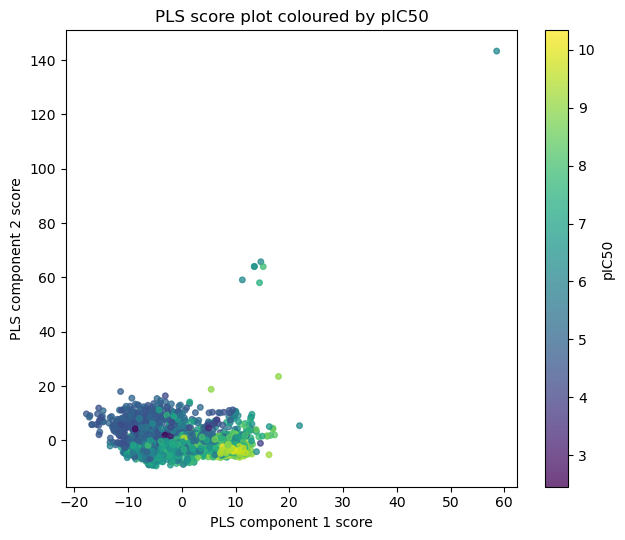

In [82]:
plt.figure(figsize=(6.5, 5.5))
scatter = plt.scatter(pls_scores_df["T1"], pls_scores_df["T2"], c=pls_scores_df["pIC50"], s=16, alpha=0.75)
plt.colorbar(scatter, label="pIC50")
plt.xlabel("PLS component 1 score")
plt.ylabel("PLS component 2 score")
plt.title("PLS score plot coloured by pIC50")
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_score_plot_t1_t2_coloured_by_pIC50.png", dpi=200)
plt.show()

# 10. Descriptor Weights, Loadings, Coefficients, and VIP Scores

Different quantities answer different questions:

- **PLS weights:** how descriptors are combined to construct latent components.
- **PLS loadings:** how descriptors relate to the latent score structure.
- **Regression coefficients:** direction and magnitude of association with pIC50 in the fitted model.
- **VIP scores:** variable-importance measure summarising descriptor contribution across selected PLS components.

In [83]:
def compute_vip(pls_model):
    T = pls_model.x_scores_
    W = pls_model.x_weights_
    Q = pls_model.y_loadings_
    p, h = W.shape
    ssy = np.sum(T ** 2, axis=0) * np.sum(Q ** 2, axis=0)
    total_ssy = np.sum(ssy)
    if total_ssy <= 0:
        return np.full(p, np.nan)
    W_norm = W / np.sqrt(np.sum(W ** 2, axis=0, keepdims=True))
    vip = np.sqrt(p * (W_norm ** 2 @ ssy) / total_ssy)
    return vip

def flatten_pls_coef(pls_model, n_features):
    coef = np.asarray(pls_model.coef_)
    if coef.shape[0] == n_features:
        return coef.reshape(n_features, -1)[:, 0]
    if coef.shape[-1] == n_features:
        return coef.reshape(-1)
    return coef.ravel()[:n_features]

n_features = len(primary_descriptors)
weights_df = pd.DataFrame(final_pls.x_weights_, columns=[f"PLS{i+1}_weight" for i in range(selected_n_components)])
weights_df.insert(0, "descriptor", primary_descriptors)
weights_df.to_csv(RESULTS_DIR / "pls_x_weights_primary_selected_model.csv", index=False)

loadings_df = pd.DataFrame(final_pls.x_loadings_, columns=[f"PLS{i+1}_x_loading" for i in range(selected_n_components)])
loadings_df.insert(0, "descriptor", primary_descriptors)
loadings_df.to_csv(RESULTS_DIR / "pls_x_loadings_primary_selected_model.csv", index=False)

corr_loading_values = []
for i in range(selected_n_components):
    score = final_pls.x_scores_[:, i]
    corr_loading_values.append([np.corrcoef(X_primary_scaled[:, j], score)[0, 1] for j in range(X_primary_scaled.shape[1])])
corr_loadings_df = pd.DataFrame(np.array(corr_loading_values).T, columns=[f"PLS{i+1}_corr_loading" for i in range(selected_n_components)])
corr_loadings_df.insert(0, "descriptor", primary_descriptors)
corr_loadings_df.to_csv(RESULTS_DIR / "pls_corr_loadings_primary_selected_model.csv", index=False)

coef_scaled = flatten_pls_coef(final_pls, n_features)
coefficients_df = pd.DataFrame({"descriptor": primary_descriptors, "coefficient_standardised_X": coef_scaled, "abs_coefficient_standardised_X": np.abs(coef_scaled)})
coefficients_df.to_csv(RESULTS_DIR / "pls_coefficients_primary_selected_model.csv", index=False)

vip_df = pd.DataFrame({"descriptor": primary_descriptors, "VIP": compute_vip(final_pls)})
vip_df["VIP_ge_1"] = vip_df["VIP"] >= 1.0
vip_df.to_csv(RESULTS_DIR / "pls_vip_scores_primary_selected_model.csv", index=False)

descriptor_metadata_cols = ["descriptor", "descriptor_category", "descriptor_numeric_type", "candidate_super_block", "is_near_constant", "is_rare_binary_like", "dominant_value_ratio"]
available_metadata_cols = [c for c in descriptor_metadata_cols if c in preprocessing_candidates.columns]
descriptor_importance = vip_df.merge(coefficients_df, on="descriptor", how="left")
descriptor_importance = descriptor_importance.merge(preprocessing_candidates[available_metadata_cols].drop_duplicates("descriptor"), on="descriptor", how="left")
descriptor_importance = descriptor_importance.sort_values("VIP", ascending=False)
descriptor_importance.to_csv(RESULTS_DIR / "pls_descriptor_importance_primary_selected_model.csv", index=False)
display(descriptor_importance.head(30))

,descriptor,VIP,VIP_ge_1,coefficient_standardised_X,abs_coefficient_standardised_X,descriptor_category,descriptor_numeric_type,candidate_super_block,is_near_constant,is_rare_binary_like,dominant_value_ratio
352,maxsOH,2.011757,True,0.065816,0.065816,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.215805
286,minsOH,2.009546,True,0.036685,0.036685,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.215805
315,maxHsOH,1.979778,True,0.109754,0.109754,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.215805
249,minHsOH,1.975399,True,-0.031663,0.031663,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.215805
439,MDEC-23,1.897334,True,0.017270,0.017270,Molecular distance edge,continuous_float_like,block_Y_topological_connectivity_structure,False,False,0.006079
432,MLogP,1.867703,True,0.026002,0.026002,Mannhold LogP,continuous_float_like,not_assigned,False,False,0.058764
54,C1SP2,1.801443,True,-0.052479,0.052479,Carbon types,integer_low_cardinality,block_Y_topological_connectivity_structure,True,False,0.486829
453,MLFER_A,1.765960,True,0.146458,0.146458,Molecular linear free energy relation,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.232016
367,LipoaffinityIndex,1.755221,True,0.025106,0.025106,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.003040
302,maxHBd,1.664281,True,0.117391,0.117391,Atom type electrotopological state,continuous_float_like,block_X_local_electronic_atom_environment,False,False,0.063323


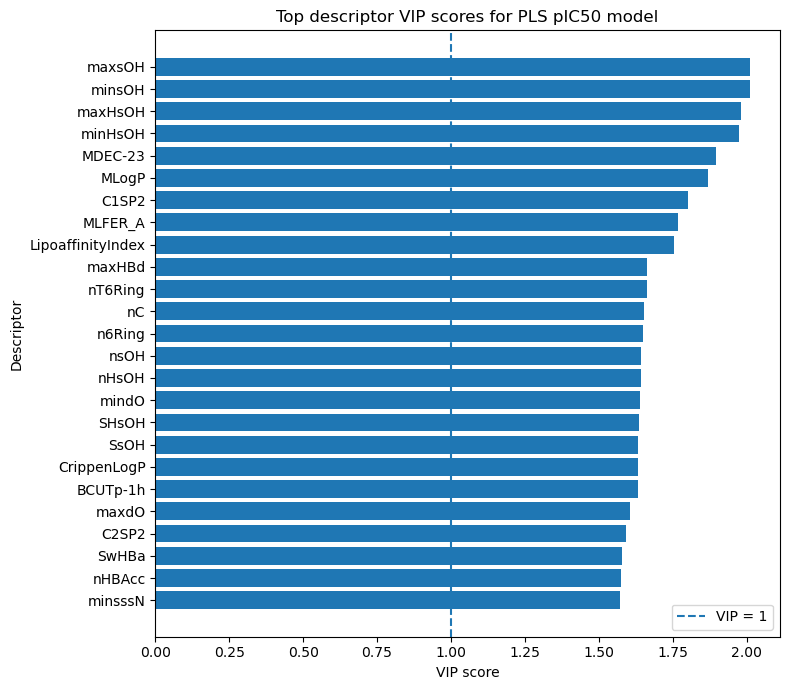

In [84]:
top_vip = descriptor_importance.sort_values("VIP", ascending=False).head(25).copy().sort_values("VIP", ascending=True)
plt.figure(figsize=(8, 7))
plt.barh(top_vip["descriptor"], top_vip["VIP"])
plt.axvline(1.0, linestyle="--", label="VIP = 1")
plt.xlabel("VIP score")
plt.ylabel("Descriptor")
plt.title("Top descriptor VIP scores for PLS pIC50 model")
plt.legend()
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "top_vip_descriptors_primary_selected_model.png", dpi=200)
plt.show()

# 11. Descriptor-Category and Super-Block Importance

,descriptor_category,n_descriptors,mean_VIP,median_VIP,max_VIP,n_VIP_ge_1,mean_abs_coefficient,sum_abs_coefficient,prop_VIP_ge_1
31,Mannhold LogP,1,1.867703,1.867703,1.867703,1,0.026002,0.026002,1.000000
19,Crippen logP and MR,2,1.522138,1.522138,1.632226,2,0.092740,0.185481,1.000000
42,Vertex adjacency information (magnitude),1,1.479322,1.479322,1.479322,1,0.009530,0.009530,1.000000
9,Autocorrelation (polarizability),5,1.478858,1.485746,1.493638,5,0.063770,0.318848,1.000000
1,APol,1,1.450489,1.450489,1.450489,1,0.002971,0.002971,1.000000
47,Zagreb index,1,1.427226,1.427226,1.427226,1,0.012782,0.012782,1.000000
17,Chi path,16,1.405854,1.425346,1.548442,16,0.039514,0.632230,1.000000
32,McGowan volume,1,1.382143,1.382143,1.382143,1,0.003315,0.003315,1.000000
41,Van der Waals volume,1,1.373019,1.373019,1.373019,1,0.000552,0.000552,1.000000
3,Aromatic atoms count,1,1.298593,1.298593,1.298593,1,0.004221,0.004221,1.000000


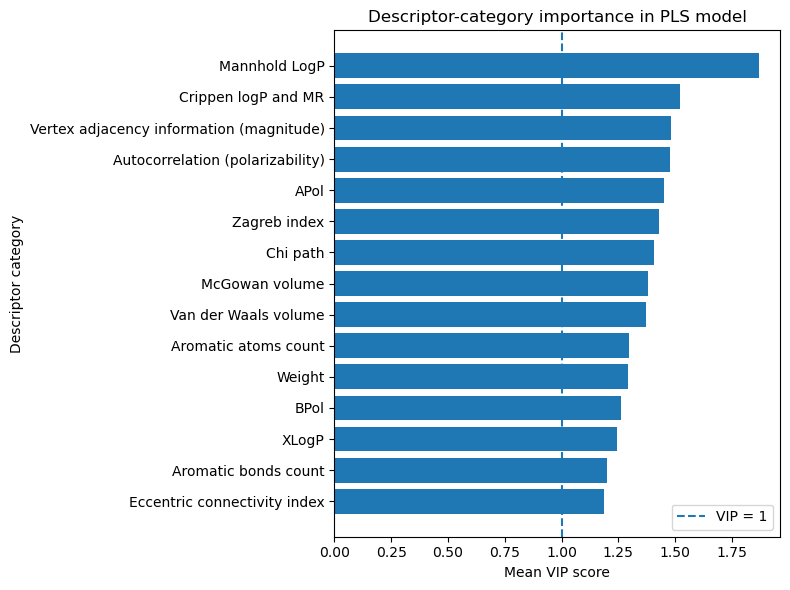

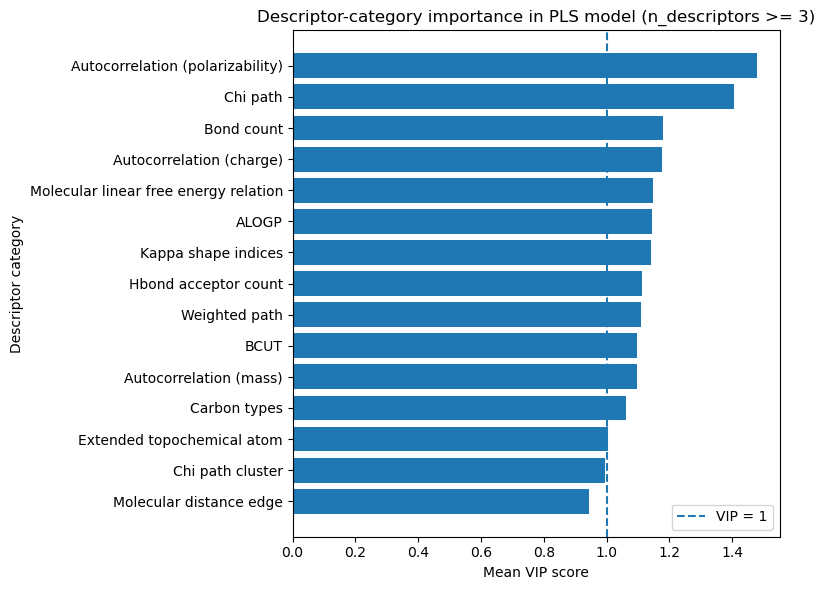

In [85]:
category_importance = (
    descriptor_importance.groupby("descriptor_category", dropna=False)
    .agg(n_descriptors=("descriptor", "count"), mean_VIP=("VIP", "mean"), median_VIP=("VIP", "median"), max_VIP=("VIP", "max"), n_VIP_ge_1=("VIP_ge_1", "sum"), mean_abs_coefficient=("abs_coefficient_standardised_X", "mean"), sum_abs_coefficient=("abs_coefficient_standardised_X", "sum"))
    .reset_index()
)
category_importance["prop_VIP_ge_1"] = category_importance["n_VIP_ge_1"] / category_importance["n_descriptors"]
category_importance = category_importance.sort_values(["mean_VIP", "max_VIP"], ascending=[False, False])
category_importance.to_csv(RESULTS_DIR / "pls_category_importance_primary_selected_model.csv", index=False)
display(category_importance.head(20))

top_category_importance = category_importance.head(15).sort_values("mean_VIP", ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(top_category_importance["descriptor_category"], top_category_importance["mean_VIP"])
plt.axvline(1.0, linestyle="--", label="VIP = 1")
plt.xlabel("Mean VIP score")
plt.ylabel("Descriptor category")
plt.title("Descriptor-category importance in PLS model")
plt.legend()
plt.tight_layout()
plt.savefig(PLS_FIGURES_DIR / "pls_category_mean_vip_importance.png", dpi=200)
plt.show()

category_plot_df = category_importance[
    category_importance["n_descriptors"] >= 3
].copy()

top_category_importance = (
    category_plot_df
    .sort_values("mean_VIP", ascending=False)
    .head(15)
    .sort_values("mean_VIP", ascending=True)
)

plt.figure(figsize=(8, 6))
plt.barh(top_category_importance["descriptor_category"], top_category_importance["mean_VIP"])
plt.axvline(1.0, linestyle="--", label="VIP = 1")
plt.xlabel("Mean VIP score")
plt.ylabel("Descriptor category")
plt.title("Descriptor-category importance in PLS model (n_descriptors >= 3)")
plt.legend()
plt.tight_layout()
plt.savefig(
    PLS_FIGURES_DIR / "pls_category_mean_vip_importance_min3_descriptors.png",
    dpi=200
)
plt.show()

,candidate_super_block,n_descriptors,mean_VIP,median_VIP,max_VIP,n_VIP_ge_1,mean_abs_coefficient,sum_abs_coefficient,prop_VIP_ge_1
2,not_assigned,40,1.115241,1.110448,1.867703,25,0.034584,1.38336,0.625000
1,block_Y_topological_connectivity_structure,129,0.980159,0.947794,1.897334,53,0.044421,5.73037,0.410853
0,block_X_local_electronic_atom_environment,335,0.890498,0.843117,2.011757,111,0.043332,14.51626,0.331343


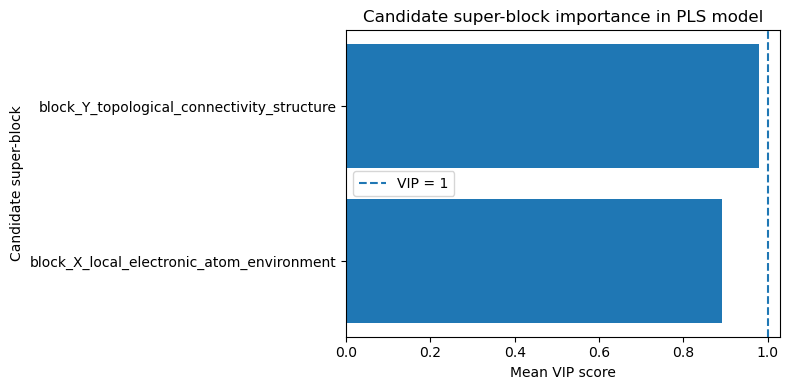

In [86]:
superblock_importance = (
    descriptor_importance.groupby("candidate_super_block", dropna=False)
    .agg(n_descriptors=("descriptor", "count"), mean_VIP=("VIP", "mean"), median_VIP=("VIP", "median"), max_VIP=("VIP", "max"), n_VIP_ge_1=("VIP_ge_1", "sum"), mean_abs_coefficient=("abs_coefficient_standardised_X", "mean"), sum_abs_coefficient=("abs_coefficient_standardised_X", "sum"))
    .reset_index()
)
superblock_importance["prop_VIP_ge_1"] = superblock_importance["n_VIP_ge_1"] / superblock_importance["n_descriptors"]
superblock_importance = superblock_importance.sort_values("mean_VIP", ascending=False)
superblock_importance.to_csv(RESULTS_DIR / "pls_candidate_super_block_importance_primary_selected_model.csv", index=False)
display(superblock_importance)

superblock_plot_df = superblock_importance[
    superblock_importance["candidate_super_block"] != "not_assigned"
].copy()

plt.figure(figsize=(8, 4))
plot_df = superblock_plot_df.sort_values("mean_VIP", ascending=True)
plt.barh(plot_df["candidate_super_block"], plot_df["mean_VIP"])
plt.axvline(1.0, linestyle="--", label="VIP = 1")
plt.xlabel("Mean VIP score")
plt.ylabel("Candidate super-block")
plt.title("Candidate super-block importance in PLS model")
plt.legend()
plt.tight_layout()
plt.savefig(
    PLS_FIGURES_DIR / "pls_candidate_super_block_mean_vip_importance_assigned_only.png",
    dpi=200
)
plt.show()

# Notes

PLS regression is an interpretable linear latent-variable model. It can identify descriptor patterns associated with ERα `pIC50`, but it does not prove causality. Nonlinear patterns observed in PCA plots or ADMET overlays do not invalidate PLS for `pIC50`; instead, they motivate residual diagnostics and possible later comparisons with nonlinear models.

The ADMET endpoints are binary variables and are not modelled directly in this notebook. They are retained for exploratory interpretation and may be studied later using classification-oriented methods if needed.